# Analysis of MNase-seq replication timing

March 25, 2024

This notebook aims to examine the raw MNase-seq data and compare to the Brewer replication timing.



In [2]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
from cc_src.mnase_replication_timing_analysis import MNaseOriginAnalysis

In [4]:
replicate = 1
chromosome = 16
mnase_analysis1 = MNaseOriginAnalysis()
mnase_analysis1.load_mnase_data(replicate, chromosome)

In [5]:
mnase_analysis1.compute_sliding_window_counts_all_times(window_size=10000, step=2500)
mnase_analysis1.normalize_samples()

In [6]:
replicate = 2
mnase_analysis2 = MNaseOriginAnalysis()
mnase_analysis2.load_mnase_data(replicate, chromosome)

In [7]:
mnase_analysis2.compute_sliding_window_counts_all_times(window_size=10000, step=2500)
mnase_analysis2.normalize_samples()

In [13]:
from src.config import load_yl_rg1_vst_config
from cc_src.chromatin_model import ChromatinModel

gene_name = "CLN2"
config_rep1 = load_yl_rg1_vst_config(1)
chromatin_model1 = ChromatinModel(config_rep1)
chromatin_model1.load_mnase_gene(gene_name)
chromatin_model1.create_deconvolution_bins()

Loading MNase reads for YPL256C/CLN2...Loading chromosome reads: 16
Done.


bin start:	62500
+1:		66785
bin end:	72500


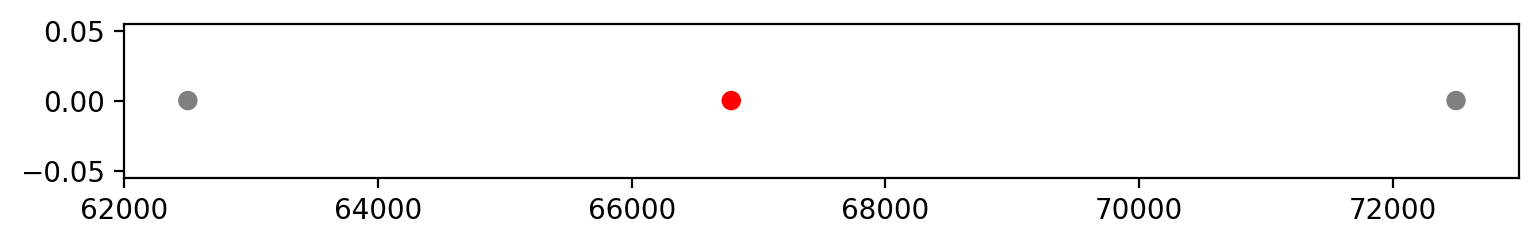

In [83]:
win = mnase_analysis1.window_size
win_2 = win//2
p1_win_2 = chromatin_model1.computed_plus_one - win_2
gene_bin_idx = np.argmax(mnase_analysis1.start_indices > p1_win_2)

gene_bin_start = mnase_analysis2.start_indices[gene_bin_idx]
xs = gene_bin_start, chromatin_model1.computed_plus_one, \
     gene_bin_start + win

plt.figure(figsize=(9, 1))
plt.scatter(xs, [0, 0, 0], c=['gray', 'red', 'gray'])
print("bin start:\t{0}\n+1:\t\t{1}\nbin end:\t{2}".format(*xs))

Text(0.5, 1.0, "Sum of counts for\ngene's 800 bp window")

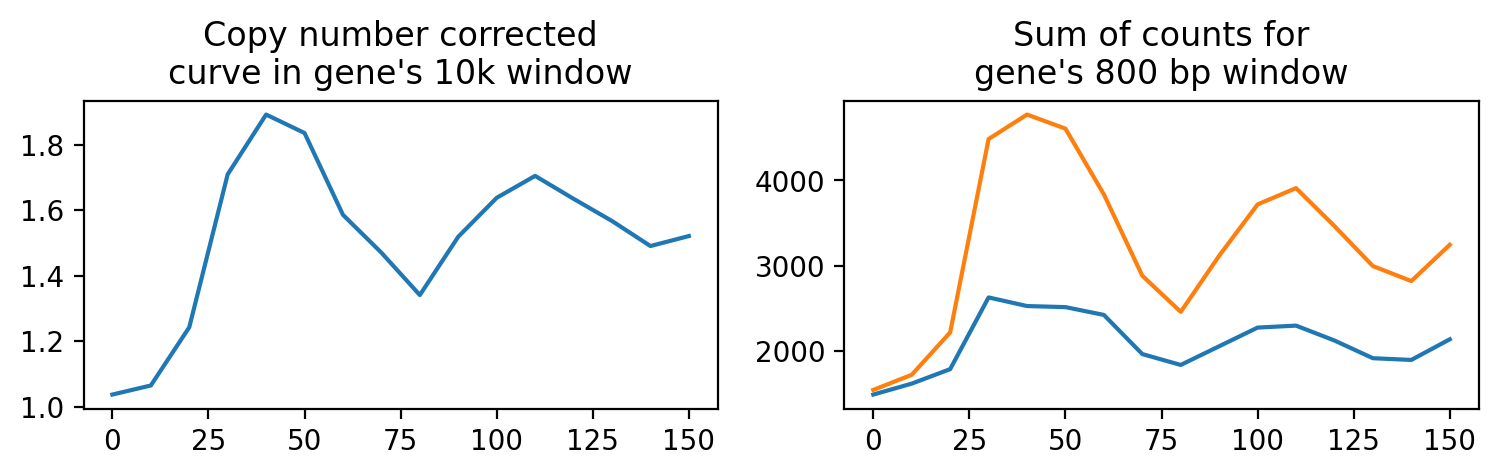

In [120]:
plt.figure(figsize=(9, 2))
tps = mnase_analysis1.timepoints
plt.subplot(1, 2, 1)
normalization = mnase_analysis1.counts_normalized_by_copy[:, gene_bin_idx]
plt.plot(tps, normalization, label="Normalization curve")
plt.title("Copy number corrected\ncurve in gene's 10k window")

plt.subplot(1, 2, 2)
original_G = chromatin_model1.G
normalized_G = chromatin_model1.G * normalization.reshape((normalization.shape[0], 1))

plt.plot(tps, original_G.sum(axis=1), label='Original')
plt.plot(tps, normalized_G.sum(axis=1), label='Normalized')
plt.title("Sum of counts for\ngene's 800 bp window")

In [106]:
chromatin_model1.G = normalized_G

In [99]:
chromatin_model1.G = original_G

In [107]:
chromatin_model1.gamma = 0.009
chromatin_model1.deconvolve()

Deconvolving with gamma=0.009, gamma_prime=0
Deconvolved in : 00:00:25.370
The fitting norm is 3.69, the smoothing norm is: 6.99


In [113]:
# orig_f = chromatin_model1.deconvolved_f_value
norm_f = chromatin_model1.deconvolved_f_value

(0.0, 1000.0)

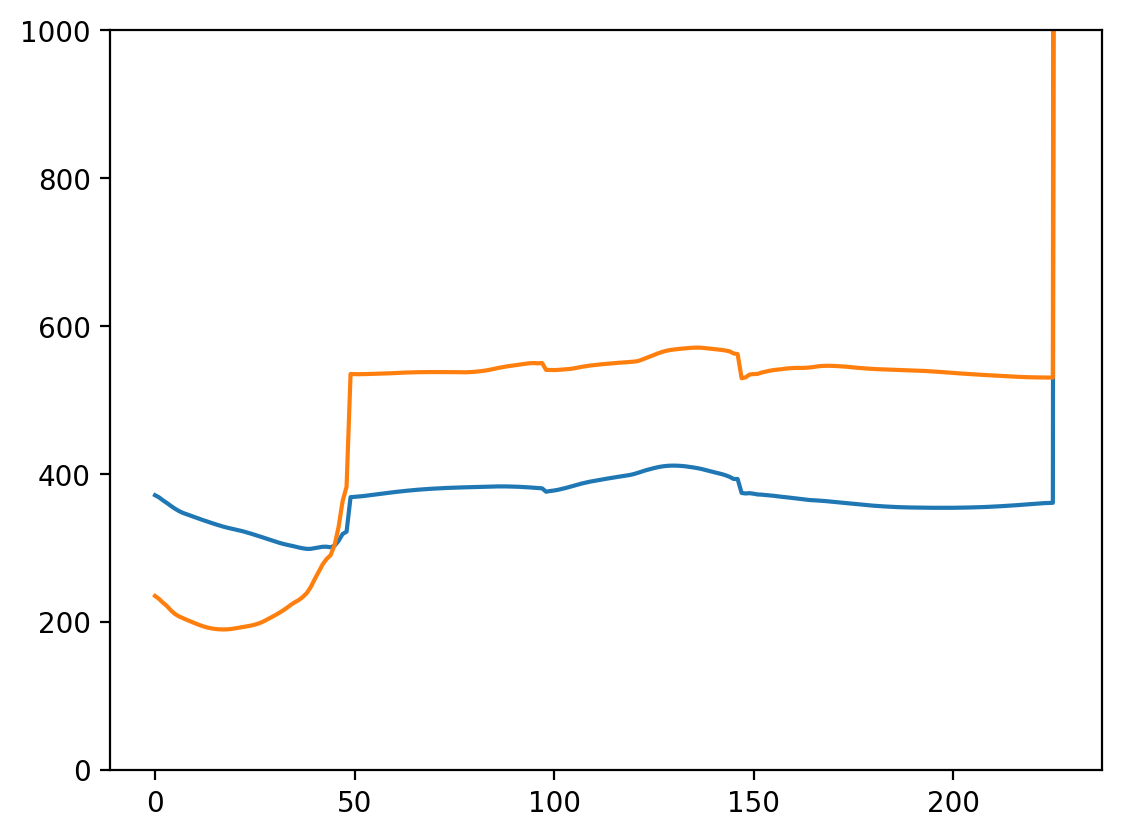

In [115]:
plt.plot(orig_f.sum(axis=1))
plt.plot(norm_f.sum(axis=1))
plt.ylim(0, 1000)

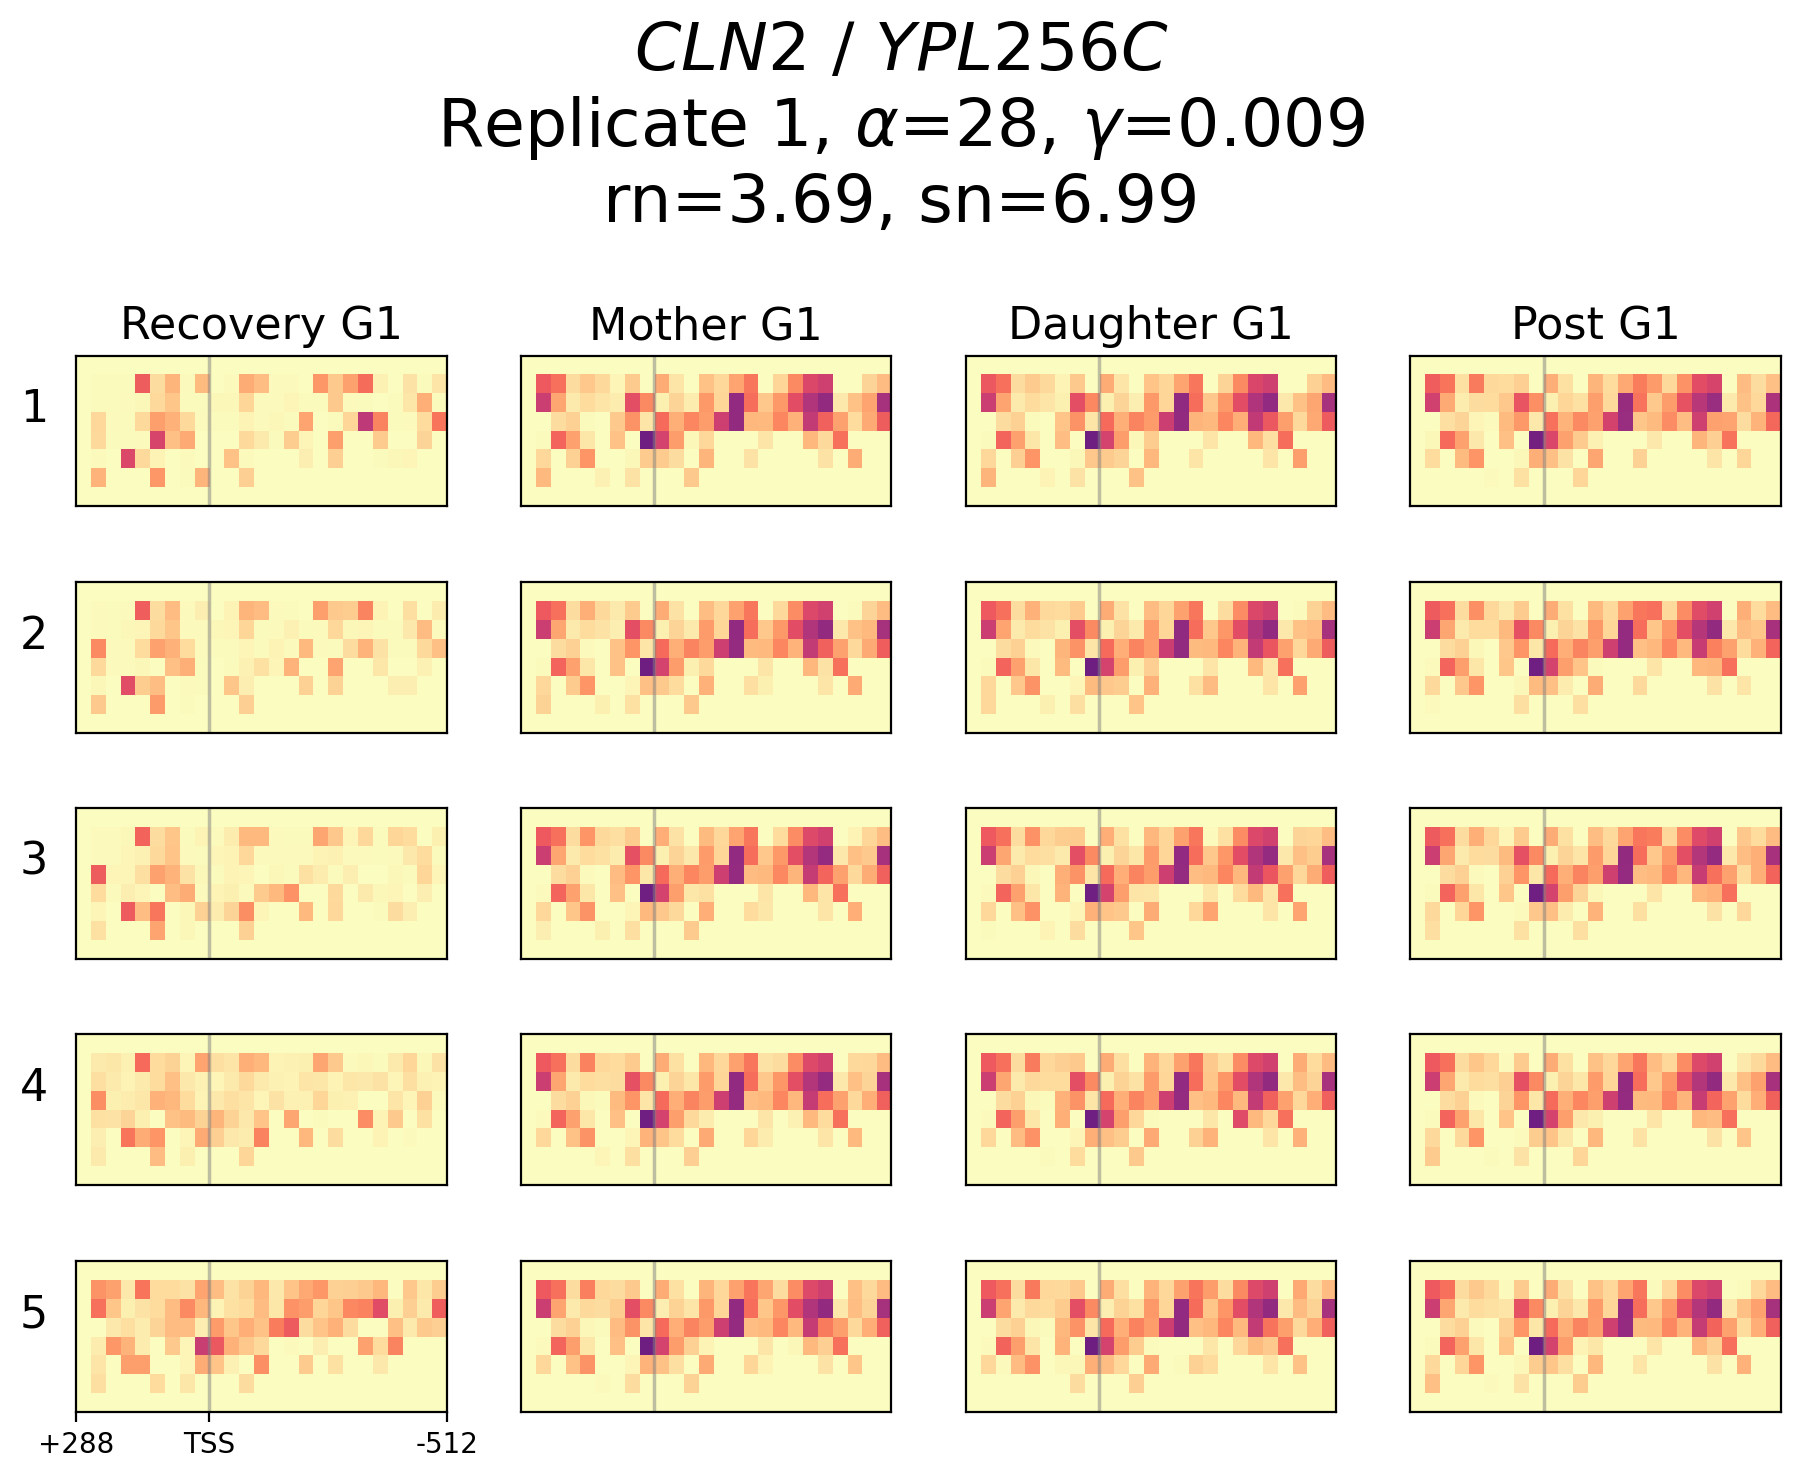

In [111]:
fig = chromatin_model1.create_deconvolution_plots_abbreviated_flipped()

In [116]:
chromatin_model1.compute_ptr()

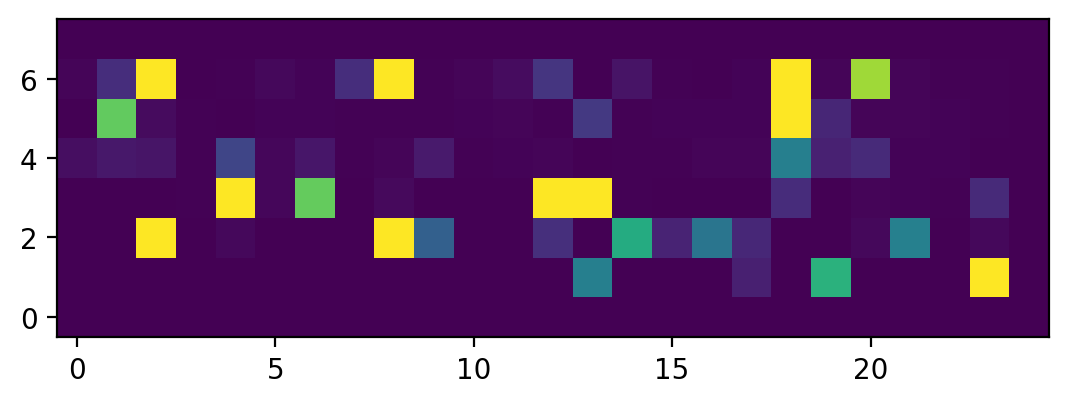

In [119]:
plt.imshow(chromatin_model1.f_ptrs.reshape(chromatin_model1.image_shape), 
           origin='lower', vmax=2, vmin=1)